# Pet Adoption Classification - part 3, optimization

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import time, warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, make_scorer,
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

warnings.filterwarnings("ignore")

colors = ['#9b5de5', '#f15bb5', '#fee440', '#00bbf9', '#00f5d4']
cmap_custom = LinearSegmentedColormap.from_list('custom', ['#ffffff', '#9b5de5'])

RANDOM_STATE = 42
TARGET = 'AdoptionLikelihood'


## Helper functions copied from part 2

In [3]:
def manual_train_test_split(df, target_column, test_size=0.2, random_state=42):
    random_generator = np.random.default_rng(random_state)
    
    train_idx = []
    test_idx = []

    for class_label in df[target_column].unique():
        class_idx = df.index[df[target_column] == class_label].tolist()
        
        random_generator.shuffle(class_idx)
        
        num_test_samples = max(1, int(len(class_idx) * test_size))
        
        test_idx.extend(class_idx[:num_test_samples])
        train_idx.extend(class_idx[num_test_samples:])

    train_set = df.loc[train_idx].sample(frac=1, random_state=random_state).reset_index(drop=True)
    test_set  = df.loc[test_idx].sample(frac=1, random_state=random_state).reset_index(drop=True)

    return train_set, test_set


def manual_stratified_kfold(df, target_column, n_splits=5, random_state=42):
    '''Generator yielding stratified (train_idx, val_idx) splits as positional indices.'''
    rng = np.random.default_rng(random_state)

    folds_per_class = {}
    for class_label in sorted(df[target_column].unique()):
        positions = np.where(df[target_column].to_numpy() == class_label)[0]
        rng.shuffle(positions)
        # Distribute this class's samples evenly into n_splits folds
        folds_per_class[class_label] = np.array_split(positions, n_splits)

    for fold_i in range(n_splits):
        val_idx = np.concatenate([folds_per_class[c][fold_i] for c in folds_per_class])
        train_idx = np.concatenate([
            folds_per_class[c][j]
            for c in folds_per_class
            for j in range(n_splits) if j != fold_i
        ])

        rng.shuffle(train_idx)
        rng.shuffle(val_idx)

        yield train_idx, val_idx

In [5]:
def manual_confusion_matrix(y_true, y_pred, num_classes=2):
    """Build a confusion matrix where rows are true labels and columns are predicted labels."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1
    return cm

def manual_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def manual_precision(y_true, y_pred, positive_class=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(np.sum((y_pred == positive_class) & (y_true == positive_class)))
    fp = int(np.sum((y_pred == positive_class) & (y_true != positive_class)))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def manual_recall(y_true, y_pred, positive_class=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(np.sum((y_pred == positive_class) & (y_true == positive_class)))
    fn = int(np.sum((y_pred != positive_class) & (y_true == positive_class)))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def manual_f1(y_true, y_pred, positive_class=1):
    p = manual_precision(y_true, y_pred, positive_class)
    r = manual_recall(y_true, y_pred, positive_class)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def manual_roc_auc(y_true, y_score):
    '''Compute ROC-AUC via trapezoidal integration of the ROC curve.'''
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # Sort samples by descending score
    order = np.argsort(-y_score, kind='mergesort')
    y_true_sorted = y_true[order]

    P = int(np.sum(y_true == 1))
    N = int(np.sum(y_true == 0))
    if P == 0 or N == 0:
        return 0.5

    # TPR = cumulative positives / total positives
    # FPR = cumulative negatives / total negatives
    tpr = np.cumsum(y_true_sorted == 1) / P
    fpr = np.cumsum(y_true_sorted == 0) / N

    # Prepend (0, 0) so curve starts at origin
    tpr = np.concatenate(([0.0], tpr))
    fpr = np.concatenate(([0.0], fpr))

    return float(np.trapezoid(tpr, fpr))

def evaluate_cv(model, train_df, feature_cols, target_col, n_splits=5, random_state=RANDOM_STATE):
    """Run stratified k-fold CV and return per-fold metric arrays."""
    fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': [], 'fit_time': []}

    for tr_idx, vl_idx in manual_stratified_kfold(train_df, target_col, n_splits=n_splits, random_state=random_state):
        X_tr = train_df.iloc[tr_idx][feature_cols].to_numpy()
        y_tr = train_df.iloc[tr_idx][target_col].to_numpy()
        X_vl = train_df.iloc[vl_idx][feature_cols].to_numpy()
        y_vl = train_df.iloc[vl_idx][target_col].to_numpy()

        # Clone-via-class-reinit is unnecessary since we instantiate fresh models per dataset.
        t0 = time.time()
        model.fit(X_tr, y_tr)
        fit_time = time.time() - t0

        y_pred = model.predict(X_vl)
        y_proba = model.predict_proba(X_vl)[:, 1]

        fold_metrics['accuracy'].append(manual_accuracy(y_vl, y_pred))
        fold_metrics['precision'].append(manual_precision(y_vl, y_pred))
        fold_metrics['recall'].append(manual_recall(y_vl, y_pred))
        fold_metrics['f1'].append(manual_f1(y_vl, y_pred))
        fold_metrics['roc_auc'].append(manual_roc_auc(y_vl, y_proba))
        fold_metrics['fit_time'].append(fit_time)

    return {k: np.array(v) for k, v in fold_metrics.items()}

## Baseline model

In [12]:
df = pd.read_csv("data_after_processing/df_knn_std.csv")

train_df, test_df = manual_train_test_split(df, TARGET, test_size=0.2, random_state=RANDOM_STATE)
feature_cols = [c for c in df.columns if c != TARGET]

baseline_model = CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0)

baseline_cv = evaluate_cv(baseline_model, train_df, feature_cols, TARGET)

baseline_row = {
    'dataset': 'df_knn_std',
    'model': 'CatBoost',
    'accuracy_mean': baseline_cv['accuracy'].mean(),
    'precision_mean': baseline_cv['precision'].mean(),
    'recall_mean': baseline_cv['recall'].mean(),
    'f1_mean': baseline_cv['f1'].mean(),
    'roc_auc_mean': baseline_cv['roc_auc'].mean(),
    'fit_time_mean': baseline_cv['fit_time'].mean()
}

df_baseline = pd.DataFrame([baseline_row])

cols_to_round = [
    'accuracy_mean',
    'precision_mean',
    'recall_mean',
    'f1_mean',
    'roc_auc_mean',
    'fit_time_mean'
]

df_baseline[cols_to_round] = df_baseline[cols_to_round].round(4)

df_baseline

,dataset,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit_time_mean
0,df_knn_std,CatBoost,0.9303,0.9207,0.8636,0.8908,0.9263,0.6285


## Feature optimization
### Correlation Matrix

In [19]:
corr_matrix = train_df[feature_cols].corr(method='pearson')

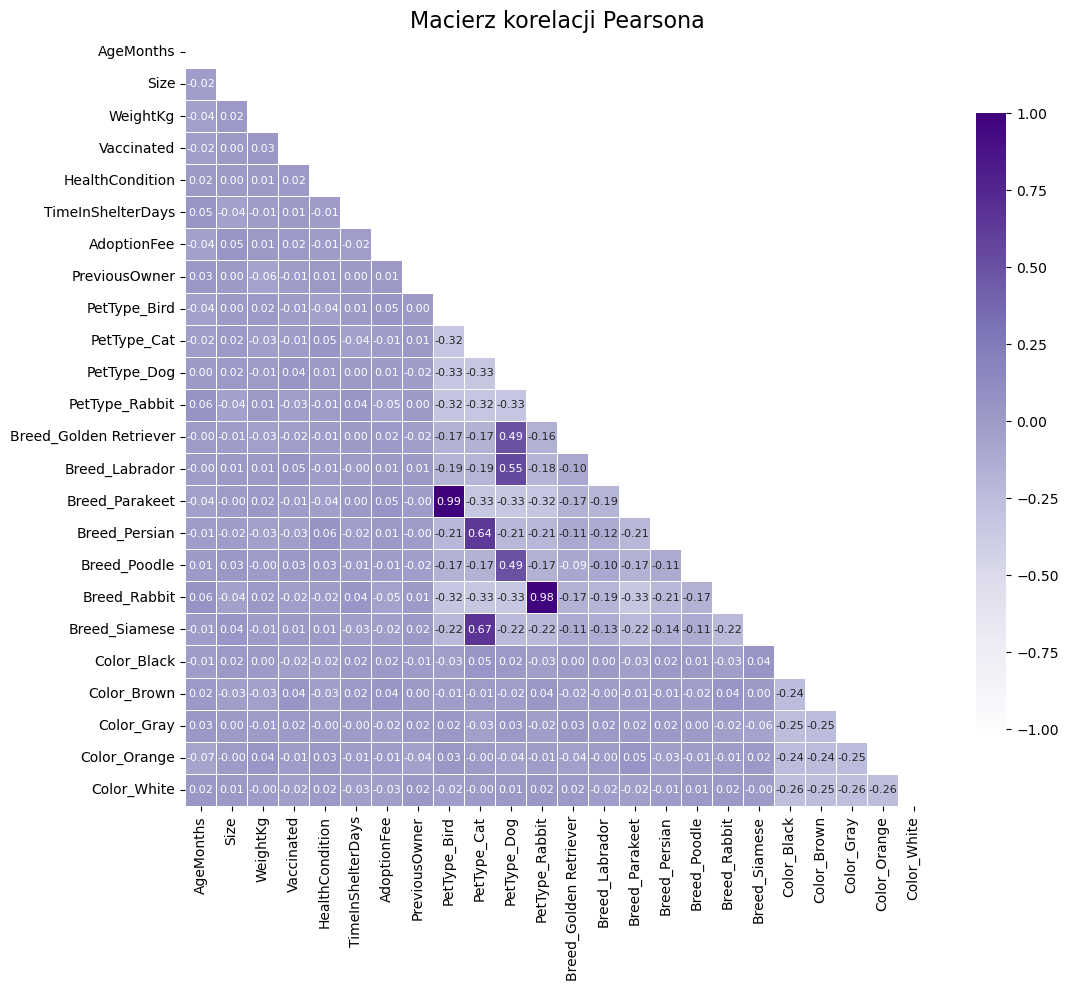

In [24]:
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    annot_kws={'size': 8},
    fmt='.2f',
    cmap='Purples',
    vmin=-1,
    vmax=1,
    center=0,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Macierz korelacji Pearsona', fontsize=16)

plt.show()

In [27]:
threshold = 0.9
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("To be deleted:", to_drop)

To be deleted: ['Breed_Parakeet', 'Breed_Rabbit']


In [29]:
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            
            var_i = train_df[col_i].var()
            var_j = train_df[col_j].var()
            
            drop_candidate = col_i if var_i < var_j else col_j
            keep_candidate = col_j if var_i < var_j else col_i
            
            print(f"Corr({col_i}, {col_j}) = {corr_matrix.iloc[i, j]:.3f} "
                  f"→ drop '{drop_candidate}' (var={train_df[drop_candidate].var():.4f}), "
                  f"keep '{keep_candidate}' (var={train_df[keep_candidate].var():.4f})")

Corr(Breed_Parakeet, PetType_Bird) = 0.987 → drop 'PetType_Bird' (var=0.1839), keep 'Breed_Parakeet' (var=0.1864)
Corr(Breed_Rabbit, PetType_Rabbit) = 0.982 → drop 'PetType_Rabbit' (var=0.1826), keep 'Breed_Rabbit' (var=0.1861)


In [28]:
# Dodatkowo możemy zostawić cechę z większą wariancją
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            
            # usuń tę z mniejszą wariancją
            if train_df[col_i].var() < train_df[col_j].var():
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)